# MLP on Iris dataset

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tensorflow.keras as keras
import keras.layers as layers
import keras.optimizers as optimizers
import keras.losses as losses

In [3]:
import sklearn

In [20]:
# load the iris dataset
import sklearn.datasets as datasets
iris = datasets.load_iris()
X = iris.data
y = iris.target

# split 80% for training and 20% for testing
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
X_test.shape, y_test.shape, X_train.shape, y_train.shape

((30, 4), (30,), (120, 4), (120,))

In [12]:
# build a model that takes 4 features as input and outputs 3 classes
model_dense = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation='relu',),
    layers.Dense(3, activation='softmax')
])

In [13]:
model_dense.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# compile the model
model_dense.compile(optimizer=optimizers.Adam(learning_rate=0.01),
                    loss=losses.SparseCategoricalCrossentropy(),
                    metrics=['accuracy'])

In [15]:
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [22]:
# train the model
history = model_dense.fit(X_train, y_train,
                          epochs=25,
                          validation_data=(X_test, y_test),
                          callbacks=[early_stopping])

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3250 - loss: 4.7299 - val_accuracy: 0.3667 - val_loss: 2.6149
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3583 - loss: 1.9590 - val_accuracy: 0.3000 - val_loss: 1.7087
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2750 - loss: 1.8310 - val_accuracy: 0.1667 - val_loss: 2.2400
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1917 - loss: 1.9675 - val_accuracy: 0.5000 - val_loss: 1.8008
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5333 - loss: 1.4204 - val_accuracy: 0.6333 - val_loss: 1.0643
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4083 - loss: 1.0064 - val_accuracy: 0.3667 - val_loss: 0.9779
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3333 - loss: 1.0515 - val_accuracy: 0.7000 - val_loss: 0.8959
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6583 - loss: 0.8681 - val_accuracy: 0.7000 - val_loss: 0.7377


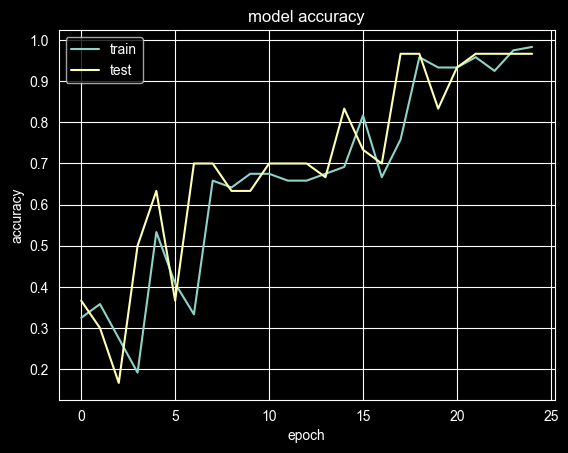

In [23]:
# evaluate the model on the test set
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

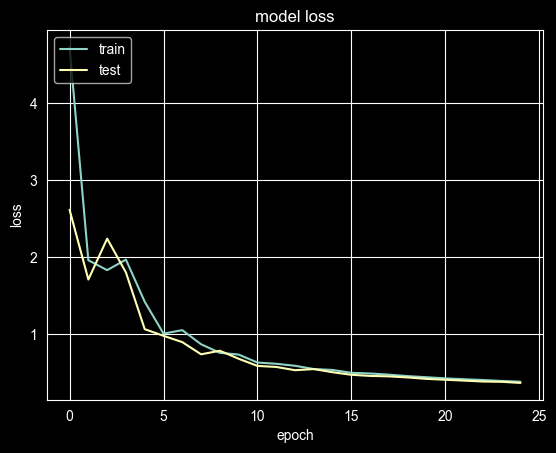

In [24]:
# evaluate the model on the test set
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [26]:
test_loss, test_acc = model_dense.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc:.3f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9667 - loss: 0.3661
Test accuracy: 0.967
